# Linear Regression — Model Implementation

This notebook implements linear regression using a **pre-built machine learning model**.

Unlike the previous notebook, we do not manually implement the cost function or gradient descent. The library handles the optimization internally.

We focus on the practical workflow:

**Data → Model → Fit → Learned parameters → Predict → Evaluate**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

X = np.array([[1], [2], [3], [4], [5], [6], [7], [8]])
y = np.array([3, 5, 7, 8, 11, 12, 14, 17])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8, 1)
y shape: (8,)


## 2. Create the Linear Regression Model

`LinearRegression()` creates a linear regression model.

The model learns parameters for:

$$
\hat{y}=wX+b
$$


In [2]:
model = LinearRegression()

## 3. Train the Model

### `model.fit(X, y)`

Trains the model using the input features `X` and target values `y`.

Internally, the model finds the parameters that minimize the squared-error objective.


In [3]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.92]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[6.48]


## 4. Get the Learned Parameters

### `model.coef_`

Returns the learned coefficient(s).

For one feature:

$$
\boxed{w=\text{model.coef_[0]}}
$$

### `model.intercept_`

Returns the learned intercept:

$$
\boxed{b=\text{model.intercept_}}
$$


In [4]:
w = model.coef_[0]
b = model.intercept_

print("Learned w:", w)
print("Learned b:", b)

Learned w: 1.9166666666666676
Learned b: 0.9999999999999964


## 5. Make Predictions

### `model.predict(X)`

Uses the learned parameters to calculate predictions for the supplied input data.

$$
\hat{y}=wX+b
$$


In [5]:
y_pred = model.predict(X)

print("Actual values:   ", y)
print("Predicted values:", np.round(y_pred, 2))

Actual values:    [ 3  5  7  8 11 12 14 17]
Predicted values: [ 2.92  4.83  6.75  8.67 10.58 12.5  14.42 16.33]


## 6. Evaluate Using RMSE

### `root_mean_squared_error(y_true, y_pred)`

Calculates **Root Mean Squared Error (RMSE)** between actual and predicted values.

$$
RMSE=
\sqrt{
\frac{1}{m}
\sum_{i=1}^{m}
(y^{(i)}-\hat{y}^{(i)})^2
}
$$

RMSE is expressed in the same units as the target variable.


In [6]:
rmse = root_mean_squared_error(y, y_pred)

print(f"RMSE: {rmse:.4f}")

RMSE: 0.4449


## 7. Visualize the Model

The points represent the original data.

The line represents the linear regression model learned by `LinearRegression()`.


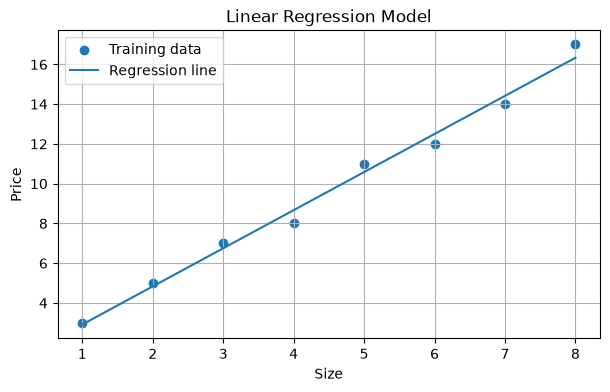

In [7]:
plt.figure(figsize=(7, 4))
plt.scatter(X, y, label="Training data")
plt.plot(X, y_pred, label="Regression line")
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Linear Regression Model")
plt.legend()
plt.grid(True)
plt.show()

## 8. Predict a New Value

We can give the trained model a new input value.

For example, suppose we want to predict the price for a house with size `9`.


In [8]:
new_X = np.array([[9]])

new_prediction = model.predict(new_X)

print("Predicted price for size 9:", new_prediction[0])

Predicted price for size 9: 18.250000000000004


## 9. Important Functions Summary

| Function / Attribute | Purpose |
|---|---|
| `LinearRegression()` | Creates the linear regression model |
| `.fit(X, y)` | Trains the model and learns the parameters |
| `.coef_` | Gives the learned coefficient(s) / weight(s) |
| `.intercept_` | Gives the learned intercept / bias |
| `.predict(X)` | Generates predictions |
| `root_mean_squared_error()` | Calculates RMSE |

### Complete workflow

```text
Create model
     ↓
model.fit(X, y)
     ↓
Learn w and b
     ↓
model.predict(X)
     ↓
Calculate RMSE
```
